In [1]:
import numpy as np
import scanpy.api as sc
import scipy as sci
import scipy.sparse
import re
import pandas
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sc.settings.verbosity = 3 # amount of output
dir_in = '/Users/david.fischer/phd/datasets/2017_Maehr_Thymus/'
dir_out = '/Users/david.fischer/phd/data/Pseudodynamics/maehr17/'
sc.settings.figdir = dir_out+'scanpy_figs/'
sc.settings.writedir = dir_out+'scanpy_1_04/'
sc.logging.print_versions()
sc.settings.set_figure_params(dpi=80, scanpy=True)
print (sys.version)

/Users/david.fischer/miniconda3/lib/python3.6/importlib/_bootstrap.py:219: RuntimeWarning: numpy.dtype size changed, may indicate binary incompatibility. Expected 96, got 88
  return f(*args, **kwds)
/Users/david.fischer/miniconda3/lib/python3.6/importlib/_bootstrap.py:219: RuntimeWarning: numpy.dtype size changed, may indicate binary incompatibility. Expected 96, got 88
  return f(*args, **kwds)


scanpy==1.2.2+94.gdd36537 anndata==0.6.6 numpy==1.15.0 scipy==1.1.0 pandas==0.23.3 scikit-learn==0.19.2 statsmodels==0.9.0 python-igraph==0.7.1 louvain==0.6.1 
3.6.5 |Anaconda, Inc.| (default, Apr 26 2018, 08:42:37) 
[GCC 4.2.1 Compatible Clang 4.0.1 (tags/RELEASE_401/final)]


Set whether adata objects are recomputed or loaded from cache.

In [2]:
bool_recomp = False

Set whether clustering is recomputed or loaded from saved .obs file. Loading makes sense if the clustering changes due to a change in scanpy or one of its dependencies and the number of clusters or the cluster labels change accordingly.

In [3]:
bool_recluster = False

Set whether cluster cache is overwritten. Note that the cache exists for reproducibility of clustering, see above.

In [4]:
bool_write_cluster_cache = False

# Summary of this notebook

#### Full data set: 
Firstly, We show the full data set and focus on the leukocyte cell types found in this data set.

#### Reduced data set
Secondly, we gate out the myeloid cells and prepare a trajectory model for the lymphoid cells found which contains a trajectory from hematopoietic stem cells to double positive T-cells and a branching trajecotry with non-conventional lymphoid cells.

# Load data

Load counts and meta data and separateley alidned TCR data.

In [5]:
if bool_recomp:
    # Count matrix:
    fn_cnts = dir_in+'blood_counts_raw.data'
    adata_raw = sc.read(fn_cnts, cache=False).transpose()
    # Meta data:
    dmeta = np.genfromtxt(dir_in+'blood_metadata_raw.data', dtype=str)
    adata_raw.obs['groups'] = dmeta[1:, 3]
    adata_raw.obs['time'] = dmeta[1:, 4].astype(float)
    adata_raw.obs['ccphase_IG1.S'] = dmeta[1:, 5].astype(float)
    adata_raw.obs['ccphase_S'] = dmeta[1:, 6].astype(float)
    adata_raw.obs['ccphase_G2.M'] = dmeta[1:, 7].astype(float)
    adata_raw.obs['ccphase_M'] = dmeta[1:, 8].astype(float)
    adata_raw.obs['ccphase_M.G1'] = dmeta[1:, 9].astype(float)
    # TCR data:
    fn_tcr = dir_in+'blood_counts_tcrcollapsed.data'
    adata_tcr = sc.read(fn_tcr, cache=False).transpose()
    # check that obseration names are the same as in adata_raw
    print(all(adata_raw.obs_names==adata_tcr.obs_names))
    for tcr in adata_tcr.var_names:
        adata_raw.obs[tcr] = np.log(adata_tcr[:,tcr].X + 1)
    sc.write(sc.settings.writedir+'adata_raw.h5ad', adata_raw)
else:
    adata_raw = sc.read(sc.settings.writedir+'adata_raw.h5ad')

Define marker sets.

In [64]:
# Leukocyte markers:
leuk_markers = ['Ptprc']
# T-cell markers: 
# CD25=Il2ra
tc_markers = ['Flt3','Cd44', 'Il2ra','Ptcra','Rag1','Rag2','Cd3e', 'Cd4', 'Cd8a', 'Cd8b1', 'Notch1', 'Bcl11b']
cd3_markers = ['Cd3d', 'Cd3e', 'Cd3g']
# alpha-beta T-cell makers (double positives):
ab_tc_markers = ['Id3', 'Rorc','Cd4', 'Cd8a', 'Cd8b1']
# gamma-delta T-cell markers:
yd_tc_markers = ['Ifng', 'Il17a']
# TCR (from separate alignment)
tcr_markers = ['TCRa', 'TCRb', 'TCRy', 'TCRd']
# Natural-killer cell markers
nk_markers = ['Il2rb', 'Ncr1', 'Klrd1', 'Klrb1b', 'Klrb1f']

# Hematopoietic stem cell markers:
sc_markers = ['Cd34']
# Myeloid cell markers: 
# Cd11c=Itgax, CD11b=Itgam, Cd16=Fcgr3
myeloid_markers = ['Itgax', 'Itgam', 'Fcgr3']
# Macrophage/monocyte markers:
# CD11b=Itgam, Ly-71=Adgre1, Lyz2: lysozyme
mp_markers = ['Adgre1', 'Lyz2']
# Dendritic cell markers
# Cd74=Cd74, CD11b=Itgam, CD13=Anpep, CD33=Cd33, CD80h=Cd80, CD83=Cd83, CD86=Cd86
dc_markers = ['Cd74', 'Anpep' , 'Cd33', 'Cd80', 'Cd83', 'Cd86'] 
# B-cell markers
bc_markers = ['Cd19']

Reduce marker sets to genes that occur in data set.

In [65]:
leuk_markers = np.array([x for x in leuk_markers if x in adata_raw.var_names])

tc_markers = np.array([x for x in tc_markers if x in adata_raw.var_names])
cd3_markers = np.array([x for x in cd3_markers if x in adata_raw.var_names])
ab_tc_markers = np.array([x for x in ab_tc_markers if x in adata_raw.var_names])
yd_tc_markers = np.array([x for x in yd_tc_markers if x in adata_raw.var_names])
nk_markers = np.array([x for x in nk_markers if x in adata_raw.var_names])

sc_markers = np.array([x for x in sc_markers if x in adata_raw.var_names])
myeloid_markers = np.array([x for x in myeloid_markers if x in adata_raw.var_names])
mp_markers = np.array([x for x in mp_markers if x in adata_raw.var_names])
dc_markers = np.array([x for x in dc_markers if x in adata_raw.var_names])
bc_markers = np.array([x for x in bc_markers if x in adata_raw.var_names])

# Full data set

## Embeddings and clustering on full data set

All pre-processing, embeddings and clustering on full data set.

In [8]:
if bool_recomp:
    adata_new = adata_raw.copy()
    adata_new.raw = sc.pp.log1p(adata_new, copy=True)
    sc.pp.recipe_weinreb17(adata_new, log=True, random_state=0) # Do log-transform.
    # No pca preprocessing necessary as this is inlcuded in sc.pp.recipe_weinreb17().
    sc.pp.neighbors(adata_new, n_neighbors=100, knn=True, method='umap', n_pcs=50, random_state=0)
    sc.tl.diffmap(adata_new)
    sc.tl.tsne(adata_new, n_jobs=3)
    if bool_recluster==True:
        sc.tl.louvain(adata_new, resolution=2.5, flavor='vtraag', random_state=0)
    else:
        obs_new = pandas.read_csv(dir_out+'scanpy_1_04/obs_maehr17_clustering.csv')
        adata_new.obs['louvain'] = pandas.Series(obs_new['louvain'].values, dtype='category')
    sc.write(sc.settings.writedir+'adata_new_full.h5ad', adata_new)
else:
    adata_new = sc.read(sc.settings.writedir+'adata_new_full.h5ad')
sc.tl.paga(adata_new)

running partition-based graph abstraction (PAGA)
    finished (0:00:01.51) --> added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)


In [9]:
if bool_recomp:
    adata_old = adata_raw.copy()
    adata_old.raw = sc.pp.log1p(adata_old, copy=True)
    sc.pp.recipe_weinreb17(adata_old, log=False, random_state=0) # Do not log-transform.
    # No pca preprocessing necessary as this is inlcuded in sc.pp.recipe_weinreb17().
    sc.pp.neighbors(adata_old, n_neighbors=100, knn=False, method='gauss', n_pcs=50, random_state=0)
    sc.tl.diffmap(adata_old)
    sc.tl.tsne(adata_old, n_jobs=3)
    sc.write(sc.settings.writedir+'adata_old_full.h5ad', adata_old)
else:
    adata_old = sc.read(sc.settings.writedir+'adata_old_full.h5ad')
adata_old.obs['louvain'] = adata_new.obs['louvain']
adata_old.uns['paga'] = adata_new.uns['paga']    

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/tsneadata_new_time_lg.pdf


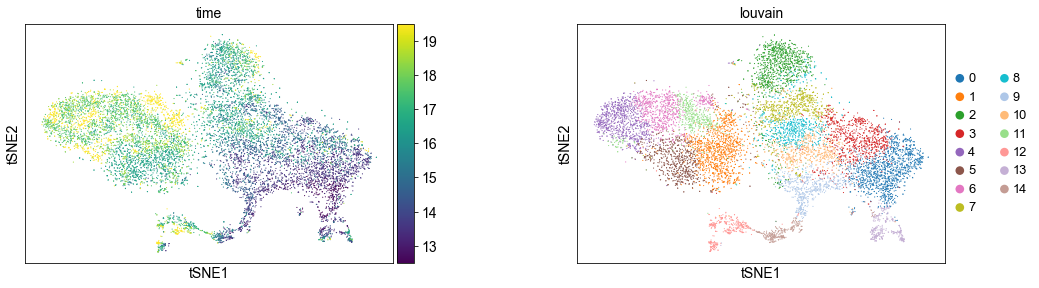

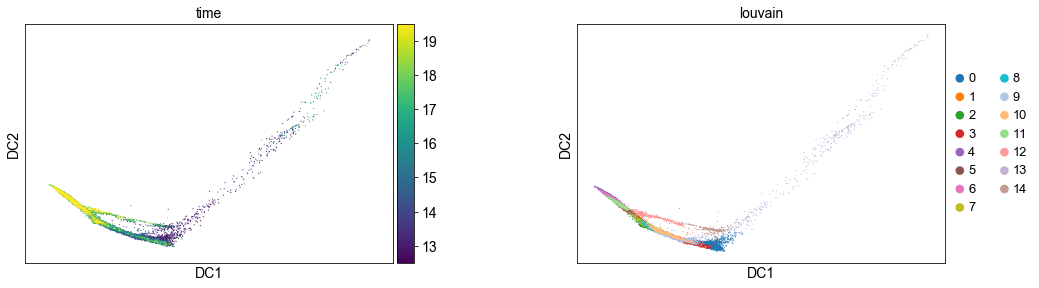

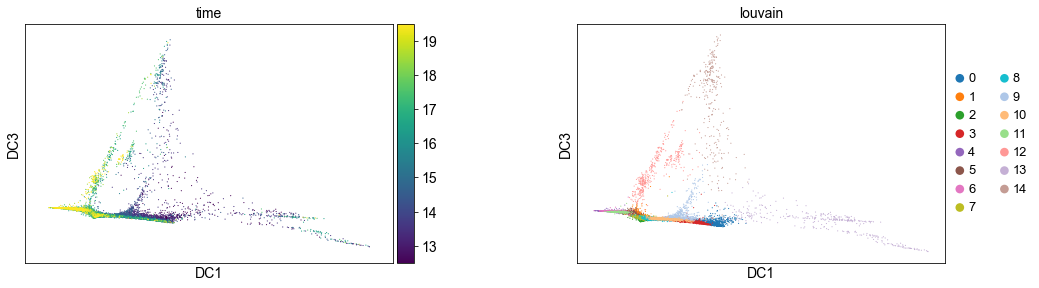

In [10]:
sc.pl.tsne(adata_new, color=['time', 'louvain'], size=5, save='adata_new_time_lg')
sc.pl.diffmap(adata_new, components='1,2', color=['time', 'louvain'], size=5)
sc.pl.diffmap(adata_new, components='1,3', color=['time', 'louvain'], size=5)

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/tsneadata_old_time_lg.pdf


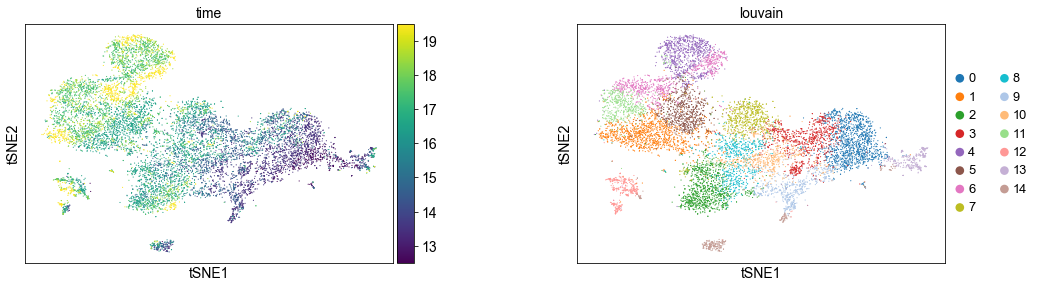

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/diffmap_components12adata_old_time_lg.pdf


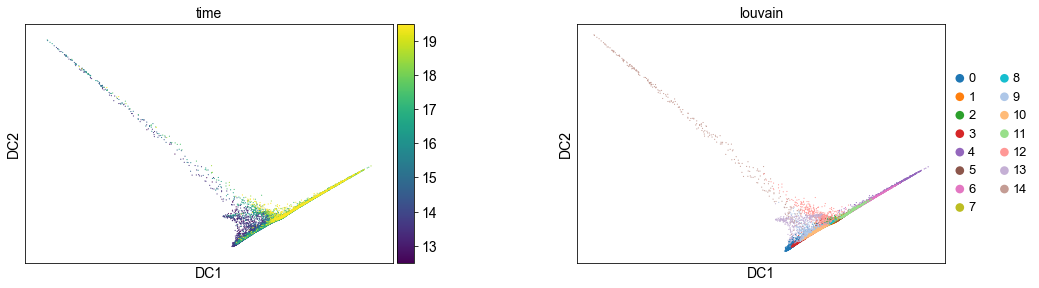

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/diffmap_components13adata_old_time_lg.pdf


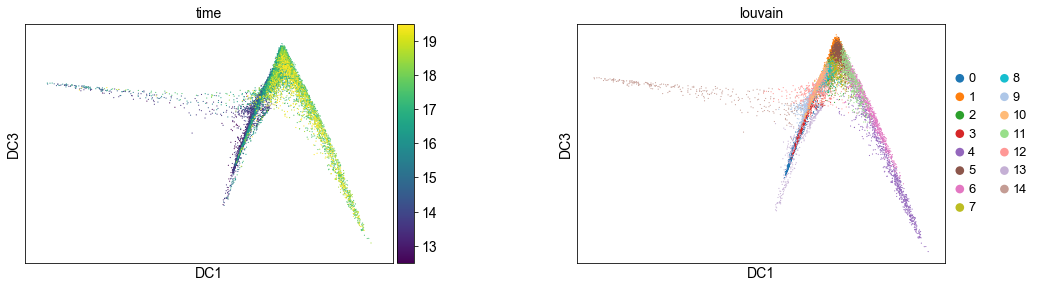

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/diffmap_components23adata_old_time_lg.pdf


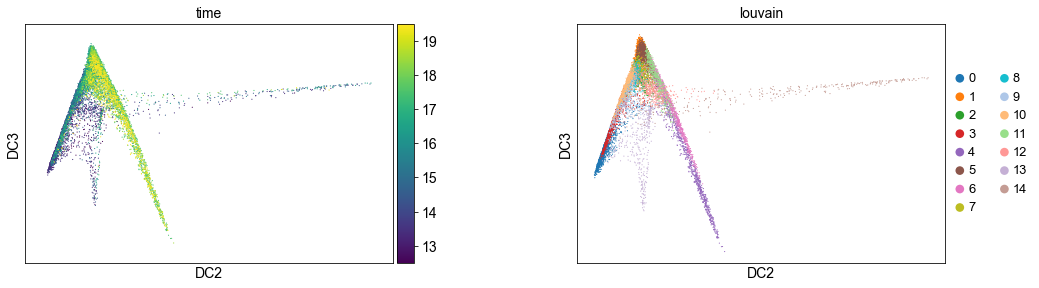

In [11]:
sc.pl.tsne(adata_old, color=['time', 'louvain'], size=5, save='adata_old_time_lg')
sc.pl.diffmap(adata_old, components='1,2', color=['time', 'louvain'], size=5, save='adata_old_time_lg')
sc.pl.diffmap(adata_old, components='1,3', color=['time', 'louvain'], size=5, save='adata_old_time_lg')
sc.pl.diffmap(adata_old, components='2,3', color=['time', 'louvain'], size=5, save='adata_old_time_lg')

## Define cell types on full data set

### Assign cell type names to louvain groups

These cell type labels are derived from the marker genes presented below but are already defined here to ease visual inspection of the marker gene distribution across clusters. We use the following marker combinations, which were presented in Yui et al., 2014, "Developmental gene networks: a triathlon on the course to T cell identity".

Stem cells: Flt3+/Cd44+

DN2a: Flt3-/Cd44+

Phase 2 (DN2b,DN3a): CD44-/CD25(Il2ra)+/Rorc-/Id3-

Phase 3 (DN3b,DN4): Rorc+/Id3+/Cd4-/Cd8+

DP: Cd4+/Cd8+

In [12]:
louvain_name_dict = {0:'0_stem', 1:'7_Phase3_1', 2:'6_Phase2_4', 3:'1_DN2a_1', 4:'11_DP_3', 
                     5:'8_Phase3_2', 6:'10_DP_2',
                     7:'5_Phase2_3', 8:'4_Phase2_2', 9:'2_DN2a_2', 10:'3_Phase2_1', 11:'9_DP_1', 
                     12:'12_NCL_ydTC', 13:'14_myeloid', 14:'13_NCL_ILC'}
adata_old.obs['louvain_named'] = [louvain_name_dict[x] for x in adata_old.obs['louvain'].values.astype(int)]
adata_new.obs['louvain_named'] = adata_old.obs['louvain_named']

phase_dict = {0:'0_stem', 1:'3_Phase3', 2:'2_Phase2', 3:'1_DN2a', 4:'4_DP', 5:'3_Phase3', 6:'4_DP',
              7:'2_Phase2', 8:'2_Phase2', 9:'1_DN2a', 10:'2_Phase2', 11:'4_DP', 
              12:'6_NCL_ydTC', 13:'7_myeloid', 14:'5_NCL_ILC'}
adata_old.obs['louvain_phase'] = [phase_dict[x] for x in adata_old.obs['louvain'].values.astype(int)]
adata_new.obs['louvain_phase'] = adata_old.obs['louvain_phase']

... storing 'louvain_named' as categorical
... storing 'louvain_phase' as categorical
saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/tsneadata_new_lg_named.pdf


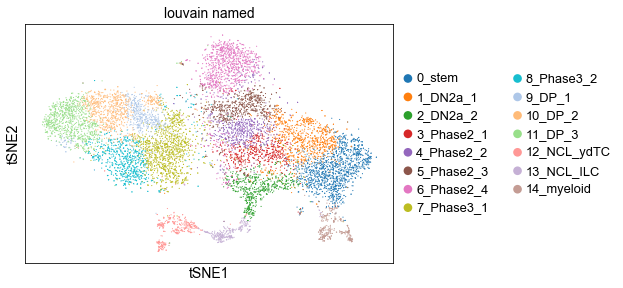

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/tsneadata_new_lg_phase.pdf


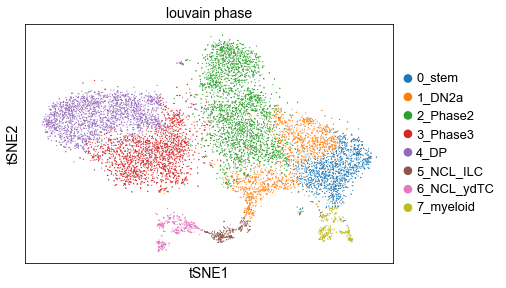

In [13]:
sc.pl.tsne(adata_new, color=['louvain_named'], size=5, save='adata_new_lg_named')
sc.pl.tsne(adata_new, color=['louvain_phase'], size=5, save='adata_new_lg_phase')

--> added 'pos', the PAGA positions (adata.uns['paga'])
saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/pagaadata_new_labeled.pdf


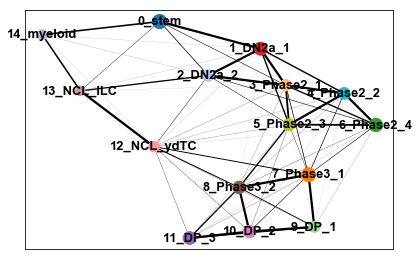

--> added 'pos', the PAGA positions (adata.uns['paga'])
saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/pagaadata_new_unlabeled.pdf


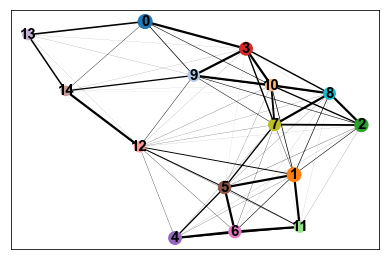

In [14]:
sc.pl.paga(adata_new, labels=[louvain_name_dict[x] for x in louvain_name_dict], 
           save='adata_new_labeled', edge_width_scale=0.3)
sc.pl.paga(adata_new, labels=None, fontsize=15, save='adata_new_unlabeled', 
           edge_width_scale=0.3)

### Check that all cells are leukocytes

... storing 'louvain_named' as categorical
... storing 'louvain_phase' as categorical
saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/violinadata_old_leukocyte_markers.pdf


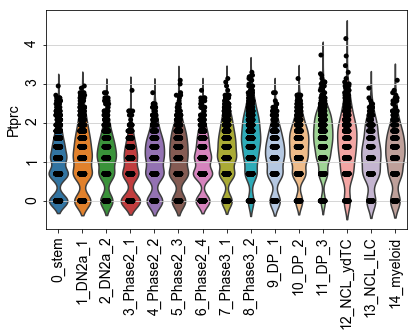

In [15]:
for i in range(len(leuk_markers) // 2 + len(leuk_markers) % 2):
    sc.pl.violin(adata_old, groupby='louvain_named', keys=leuk_markers[(2*i):np.min([2*(i+1), len(leuk_markers)])], 
                 use_raw=True, rotation=90, size=5, save='adata_old_leukocyte_markers')

### hematopoietic stem cells

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/violinadata_old_sc_markers.pdf


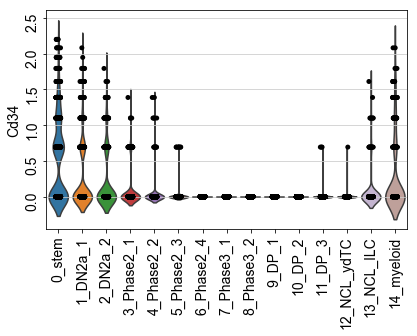

In [16]:
for i in range(len(sc_markers) // 2 + len(sc_markers) % 2):
    sc.pl.violin(adata_old, groupby='louvain_named', keys=sc_markers[(2*i):np.min([2*(i+1), len(sc_markers)])], 
                 use_raw=True, rotation=90, size=5, save='adata_old_sc_markers')

### Select T-cells and their subgroups

T-cells

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/violinadata_old_tc_markers0.pdf


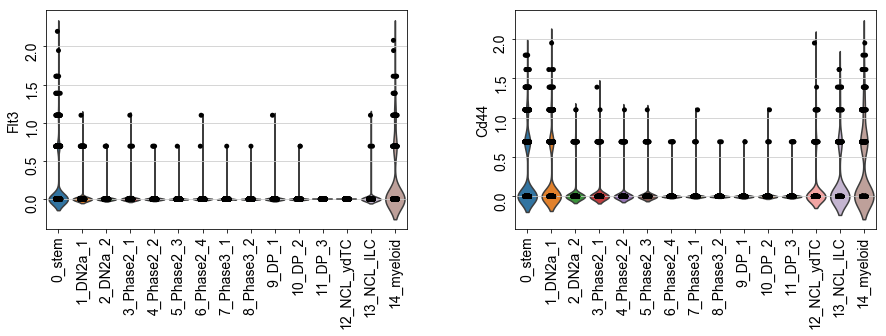

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/violinadata_old_tc_markers1.pdf


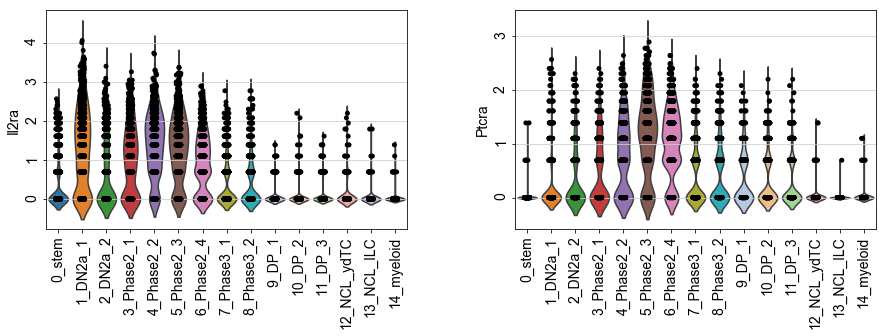

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/violinadata_old_tc_markers2.pdf


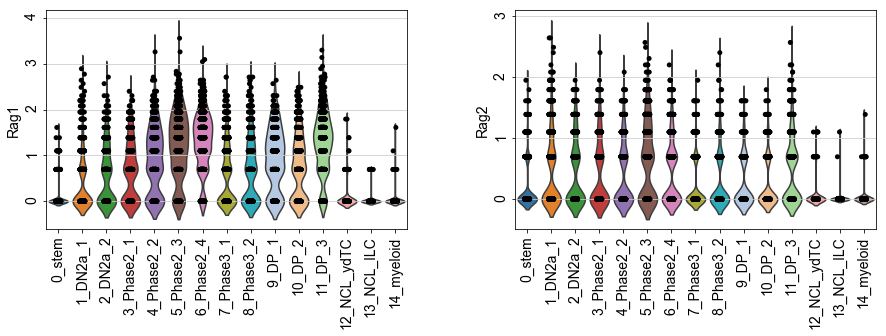

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/violinadata_old_tc_markers3.pdf


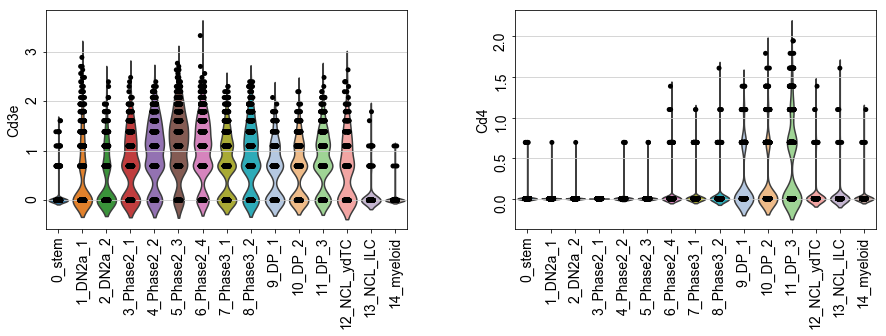

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/violinadata_old_tc_markers4.pdf


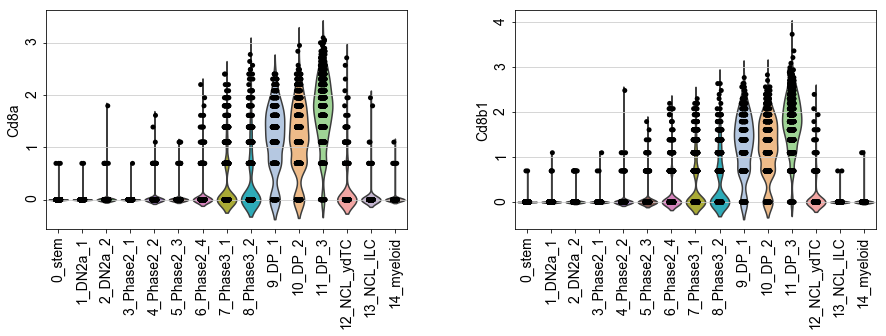

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/violinadata_old_tc_markers5.pdf


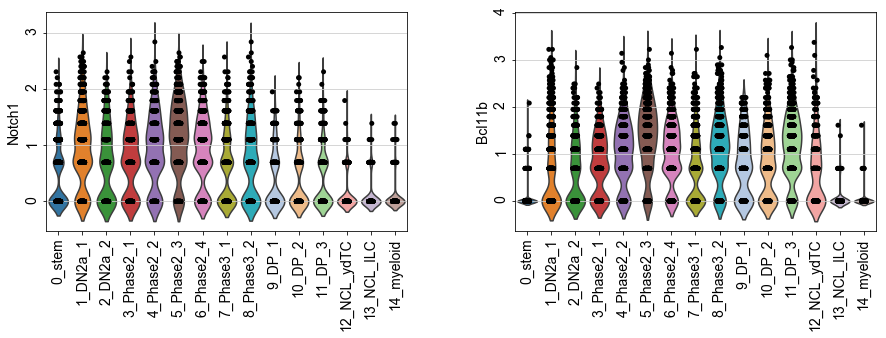

In [17]:
for i in range(len(tc_markers) // 2 + len(tc_markers) % 2):
    sc.pl.violin(adata_old, groupby='louvain_named', keys=tc_markers[(2*i):np.min([2*(i+1), len(tc_markers)])], 
                 use_raw=True, rotation=90, size=5, save='adata_old_tc_markers'+str(i))

TCR expression (T-cells)

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/violinadata_old_tcr0.pdf


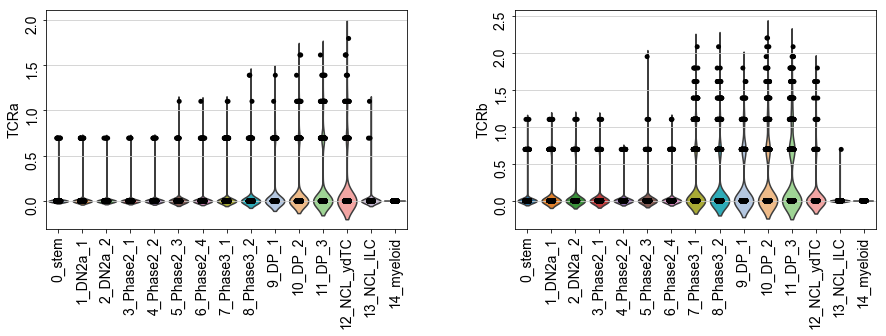

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/violinadata_old_tcr1.pdf


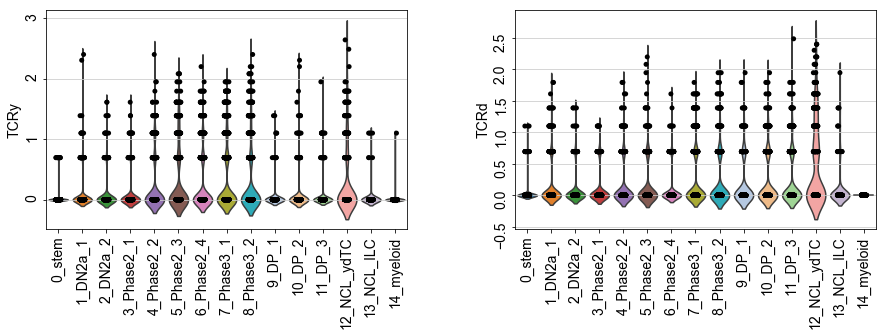

In [18]:
for i in range(len(tcr_markers) // 2 + len(tcr_markers) % 2):
    sc.pl.violin(adata_old, groupby='louvain_named', keys=tcr_markers[(2*i):np.min([2*(i+1), len(tcr_markers)])], 
                 use_raw=True, rotation=90, size=5, save='adata_old_tcr'+str(i))

Cd3 expression

... storing 'gated_monocle2' as categorical
saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/violinadata_old_cd3_markers0.pdf


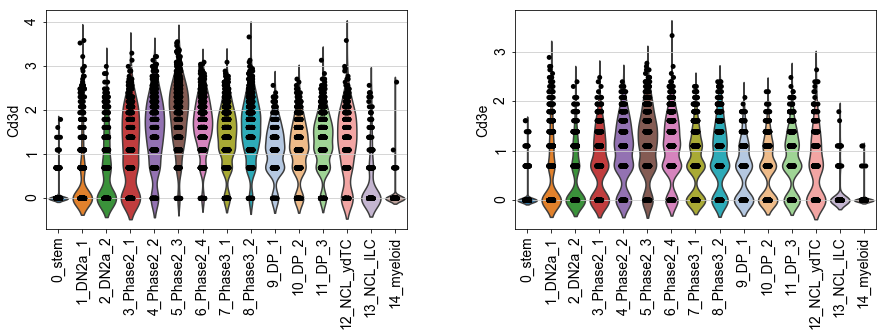

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/violinadata_old_cd3_markers1.pdf


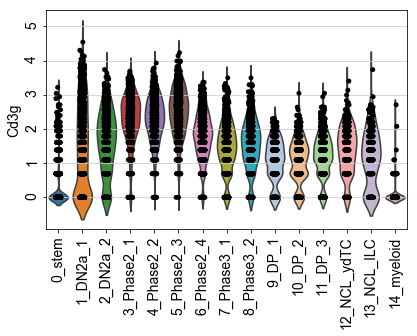

In [68]:
for i in range(len(cd3_markers) // 2 + len(cd3_markers) % 2):
    sc.pl.violin(adata_old, groupby='louvain_named', keys=cd3_markers[(2*i):np.min([2*(i+1), len(cd3_markers)])], 
                 use_raw=True, rotation=90, size=5, save='adata_old_cd3_markers'+str(i))

alpha-beta T-cells

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/violinadata_old_abtc_markers0.pdf


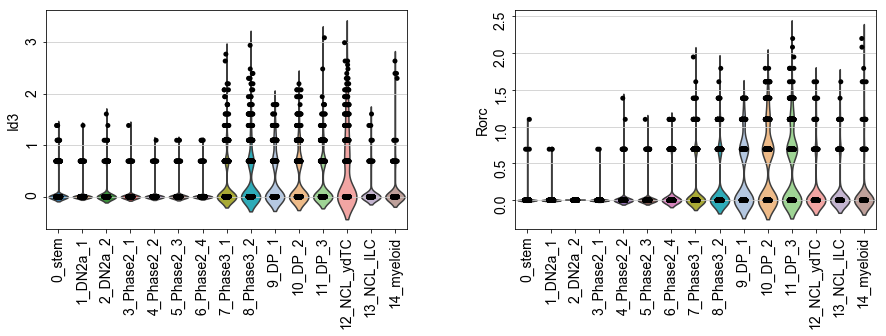

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/violinadata_old_abtc_markers1.pdf


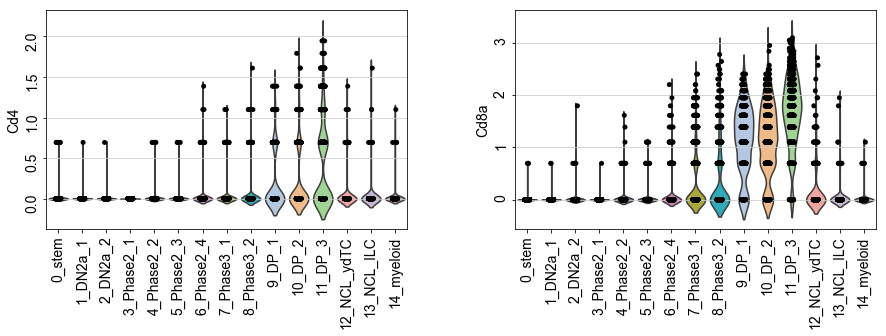

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/violinadata_old_abtc_markers2.pdf


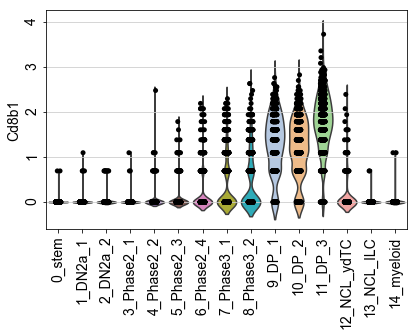

In [19]:
for i in range(len(ab_tc_markers) // 2 + len(ab_tc_markers) % 2):
    sc.pl.violin(adata_old, groupby='louvain_named', keys=ab_tc_markers[(2*i):np.min([2*(i+1), len(ab_tc_markers)])], 
                 use_raw=True, rotation=90, size=5, save='adata_old_abtc_markers'+str(i))

gamma-delta T-cells

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/violinadata_old_ydtc_markers0.pdf


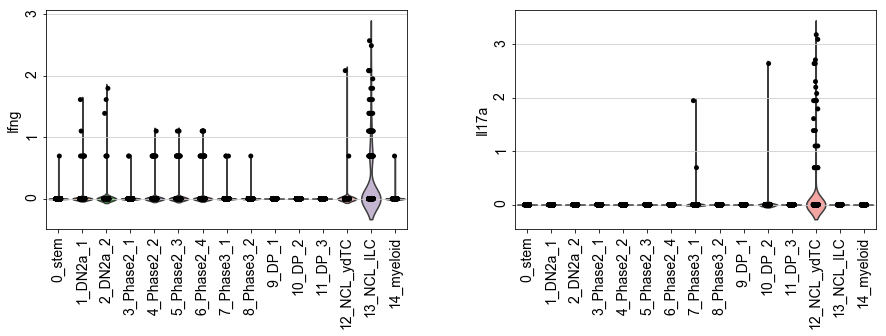

In [20]:
for i in range(len(yd_tc_markers) // 2 + len(yd_tc_markers) % 2):
    sc.pl.violin(adata_old, groupby='louvain_named', keys=yd_tc_markers[(2*i):np.min([2*(i+1), len(yd_tc_markers)])], 
                 use_raw=True, rotation=90, size=5, save='adata_old_ydtc_markers'+str(i))

### other lymphoid cells

natural killer cells

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/violinadata_old_nk_markers0.pdf


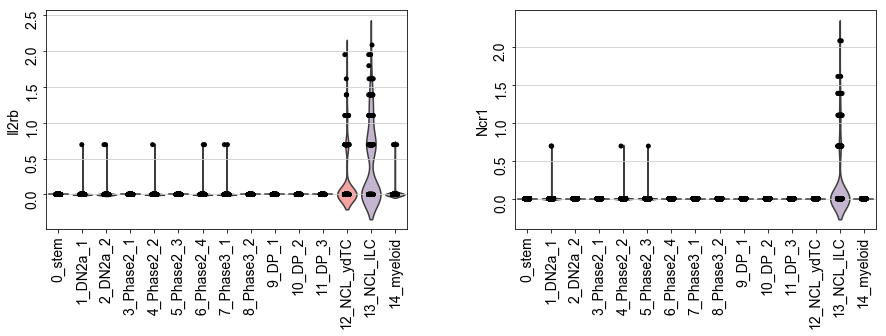

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/violinadata_old_nk_markers1.pdf


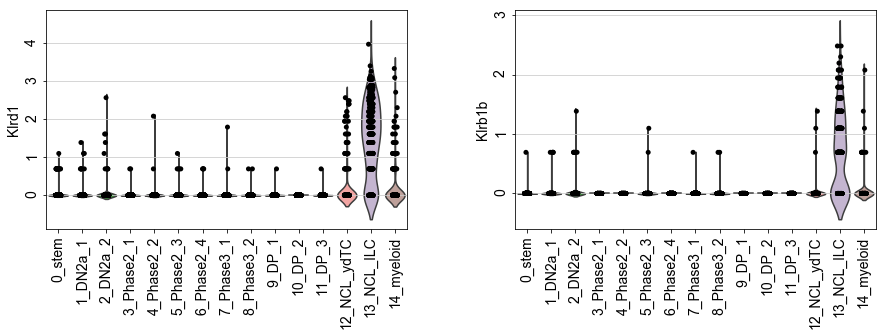

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/violinadata_old_nk_markers2.pdf


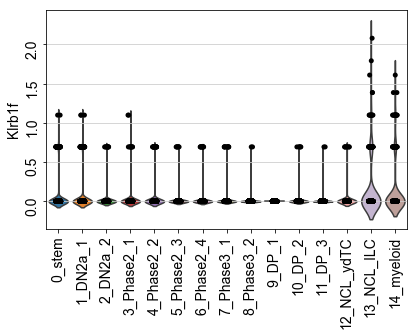

In [21]:
for i in range(len(nk_markers) // 2 + len(nk_markers) % 2):
    sc.pl.violin(adata_old, groupby='louvain_named', keys=nk_markers[(2*i):np.min([2*(i+1), len(nk_markers)])], 
                 use_raw=True, rotation=90, size=5, save='adata_old_nk_markers'+str(i))

B-cells

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/violinadata_old_bc_markers0.pdf


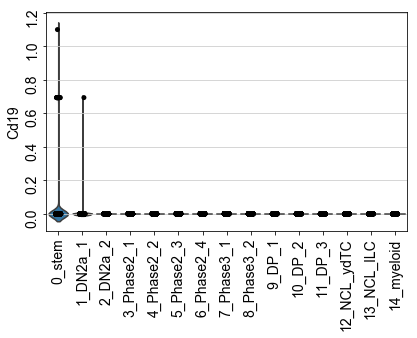

In [22]:
for i in range(len(bc_markers) // 2 + len(bc_markers) % 2):
    sc.pl.violin(adata_old, groupby='louvain_named', keys=bc_markers[(2*i):np.min([2*(i+1), len(bc_markers)])], 
                 use_raw=True, rotation=90, size=5, save='adata_old_bc_markers'+str(i))

### myeloid cells

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/violinadata_old_myeloid_markers0.pdf


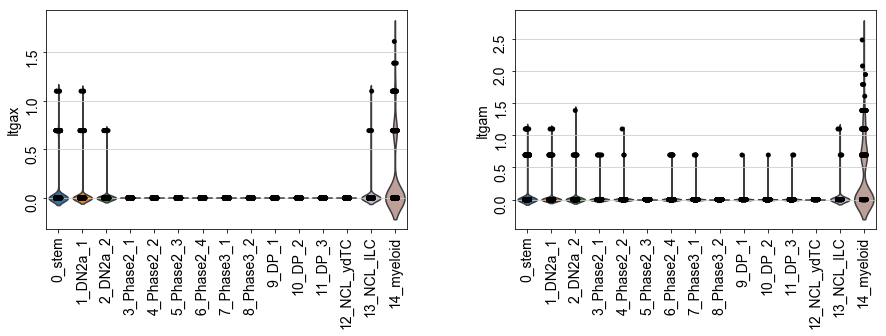

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/violinadata_old_myeloid_markers1.pdf


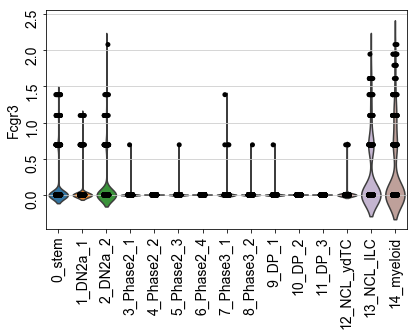

In [23]:
for i in range(len(myeloid_markers) // 2 + len(myeloid_markers) % 2):
    sc.pl.violin(adata_old, groupby='louvain_named', keys=myeloid_markers[(2*i):np.min([2*(i+1), len(myeloid_markers)])], 
                 use_raw=True, rotation=90, size=5, save='adata_old_myeloid_markers'+str(i))

macrophages

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/violinadata_old_macrophage_markers0.pdf


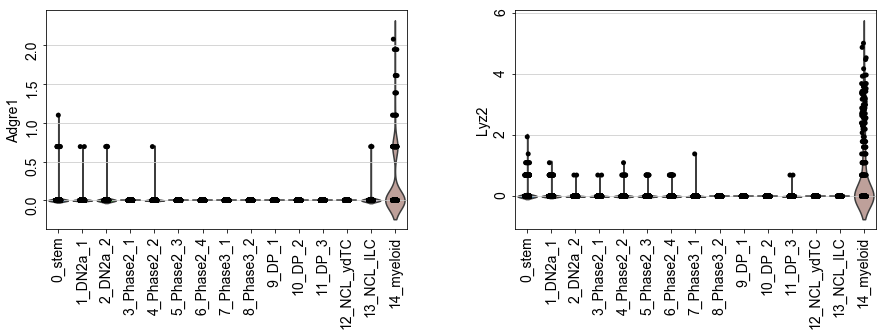

In [24]:
for i in range(len(mp_markers) // 2 + len(mp_markers) % 2):
    sc.pl.violin(adata_old, groupby='louvain_named', keys=mp_markers[(2*i):np.min([2*(i+1), len(mp_markers)])], 
                 use_raw=True, rotation=90, size=5, save='adata_old_macrophage_markers'+str(i))

dendritic cells

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/violinadata_old_dc_markers0.pdf


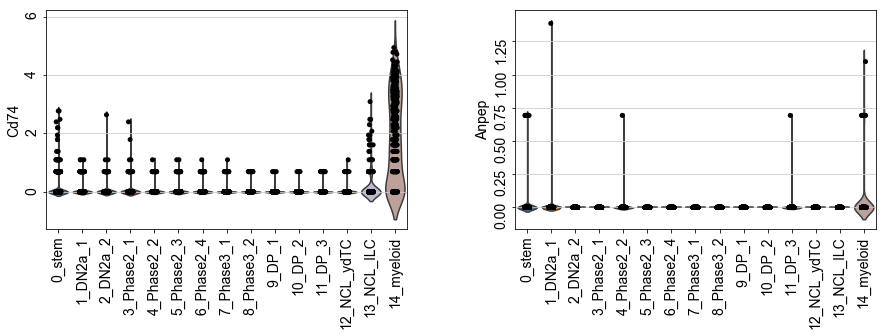

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/violinadata_old_dc_markers1.pdf


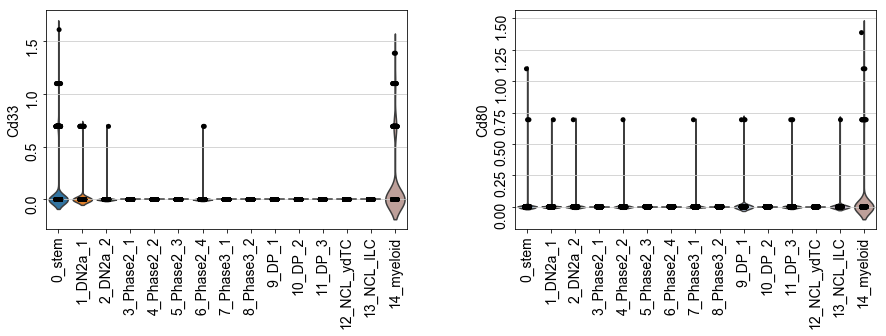

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/violinadata_old_dc_markers2.pdf


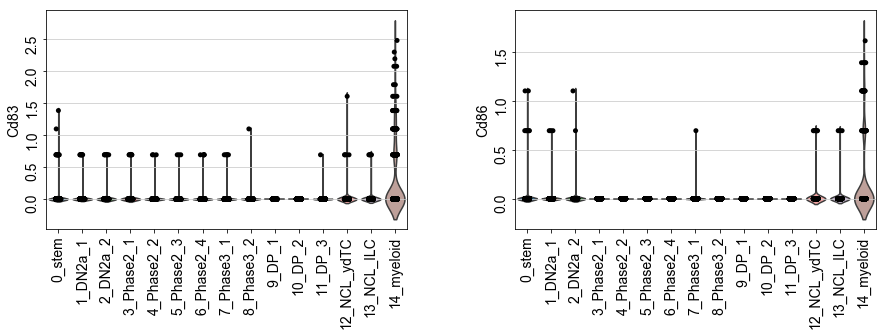

In [25]:
for i in range(len(dc_markers) // 2 + len(dc_markers) % 2):
    sc.pl.violin(adata_old, groupby='louvain_named', keys=dc_markers[(2*i):np.min([2*(i+1), len(dc_markers)])], 
                 use_raw=True, rotation=90, size=5, save='adata_old_dc_markers'+str(i))

#### Distinguish monocytes and dendritic cells: subcluster myeloid cluster.

Dendritic cell marker CD74 and macrophage marker lysozyme (Lyz2) seperate out in t-SNE.

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/tsneadata_old_myeloid_clusters.pdf


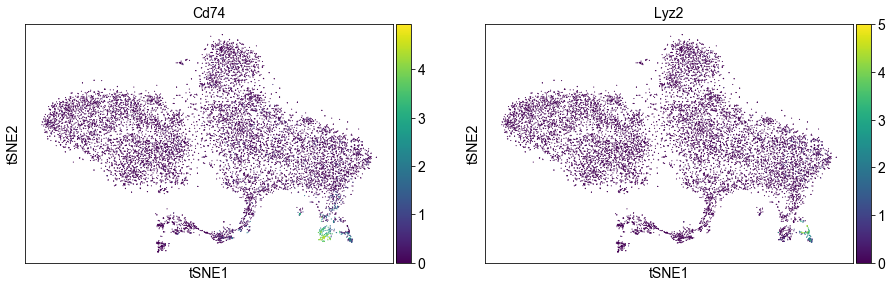

In [26]:
sc.pl.tsne(adata_new, color=['Cd74', 'Lyz2'], use_raw=True, size=5, save='adata_old_myeloid_clusters')

Subcluster myeloid cluster.

In [27]:
if bool_recomp:
    adata_myeloid = adata_raw.copy()
    adata_myeloid.obs['louvain'] = adata_new.obs['louvain']
    adata_myeloid.obs['louvain_named'] = adata_new.obs['louvain_named']
    # take out putative DC
    adata_myeloid = adata_myeloid[np.where([x=='14_myeloid' for x in adata_myeloid.obs['louvain_named']])[0],:]
    adata_myeloid.raw = sc.pp.log1p(adata_myeloid, copy=True)
    sc.pp.recipe_weinreb17(adata_myeloid, log=True)
    # No pca preprocessing necessary as this is inlcuded in sc.pp.recipe_weinreb17().
    sc.pp.neighbors(adata_myeloid, n_neighbors=100, knn=True, method='umap', n_pcs=50, random_state=0)
    sc.tl.tsne(adata_myeloid, n_jobs=3)
    sc.tl.louvain(adata_myeloid, resolution=1, flavor='vtraag', random_state=0)
    sc.write(sc.settings.writedir+'adata_myeloid.h5ad', adata_myeloid)
else:
    adata_myeloid = sc.read(sc.settings.writedir+'adata_myeloid.h5ad')

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/tsneadata_myeloid_lg.pdf


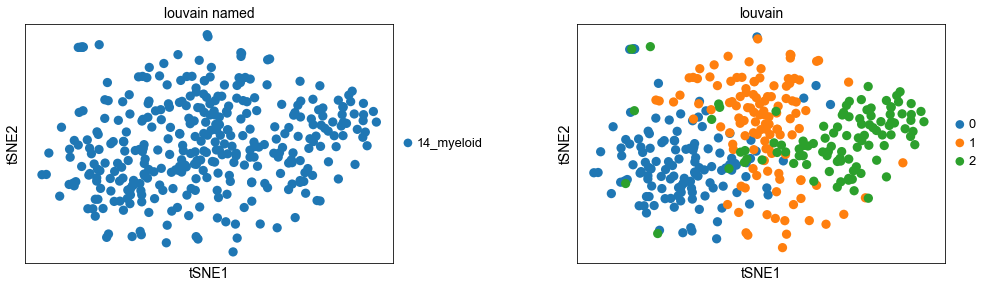

In [28]:
sc.pl.tsne(adata_myeloid, color=['louvain_named', 'louvain'], use_raw=True, save='adata_myeloid_lg')

Marker gene distribution across sub-clusters:

saving figure to file /Users/david.fischer/phd/data/Pseudodynamics/maehr17/scanpy_figs/violinadata_myeloid_lg.pdf


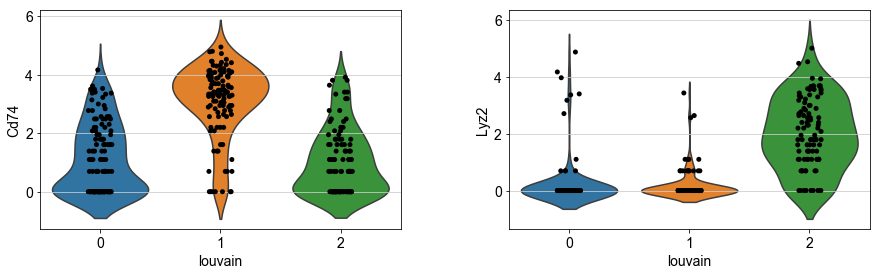

In [29]:
sc.pl.violin(adata_myeloid, groupby='louvain', keys=['Cd74', 'Lyz2'], use_raw=True, size=5, save='adata_myeloid_lg')

# Reduced data set

In [30]:
idxRoot = np.argmin(adata_old.obsm['X_diffmap'][:,2])
print(idxRoot) # 191
adata_old.uns['iroot'] = idxRoot

191


In [31]:
if bool_recomp:
    sc.tl.dpt(adata_old, n_branchings=1,
              n_dcs=10, min_group_size=100, allow_kendall_tau_shift=True)
    sc.write(sc.settings.writedir+'adata_old_full.h5ad', adata_old)

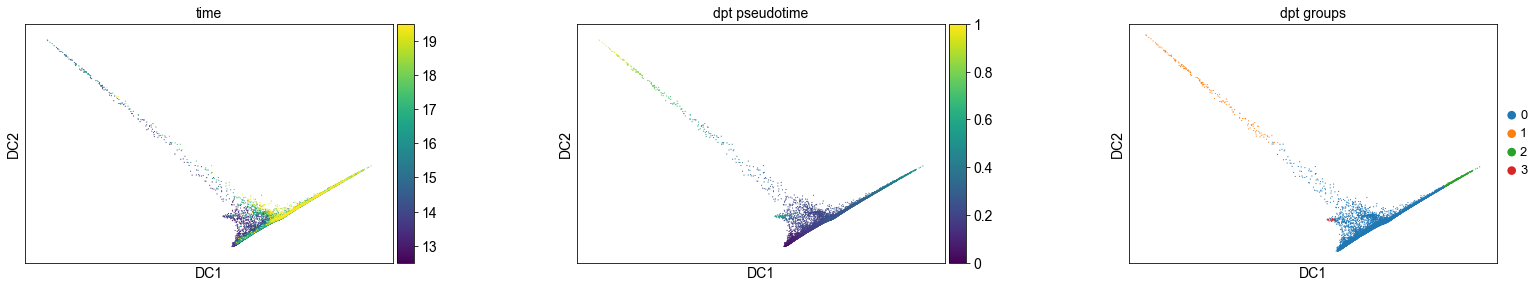

In [32]:
sc.pl.diffmap(adata_old, components='1,2', color=['time', 'dpt_pseudotime', 'dpt_groups'], size=5)

## Create, pre-process, embeddings, clusterings of/for reduced data set

In [33]:
if bool_recomp:
    adata_old_red = adata_old.copy()
    adata_old_red.obs['dpt_groups'] = adata_old.obs['dpt_groups']
    ## Gate out myeloid cells / dendritic cells:
    # Based on louvain groups: This would be a new workflow.
    #adata_old_red = adata_old_red[np.where([x!='14_myeloid' for x in adata_old_red.obs['louvain_named']])[0],:]
    # Based on dpt_groups (dpt branching analysis): This is the workflow used in the paper.
    adata_old_red = adata_old_red[np.where([x!='3' for x in adata_old_red.obs['dpt_groups']])[0],:]
    # Recompute neighbourhood and diffusion map on reduced data set:
    sc.pp.neighbors(adata_old_red, n_neighbors=100, knn=False, method='gauss', n_pcs=50)
    sc.tl.diffmap(adata_old_red)
    sc.write(sc.settings.writedir+'adata_old_red.h5ad', adata_old_red)
else:
    adata_old_red = sc.read(sc.settings.writedir+'adata_old_red.h5ad')

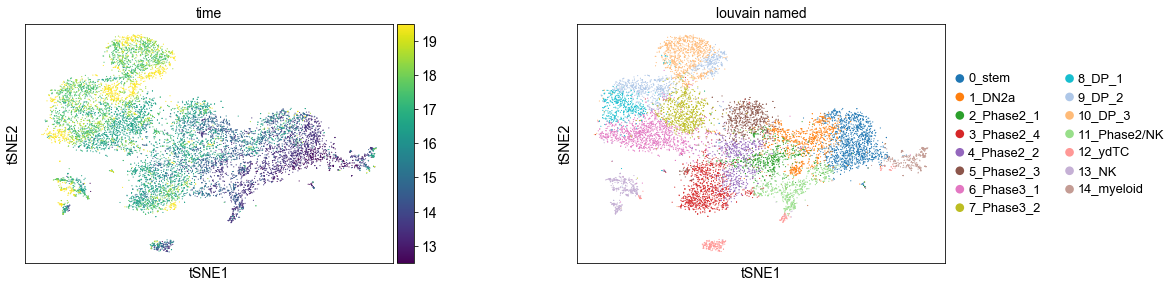

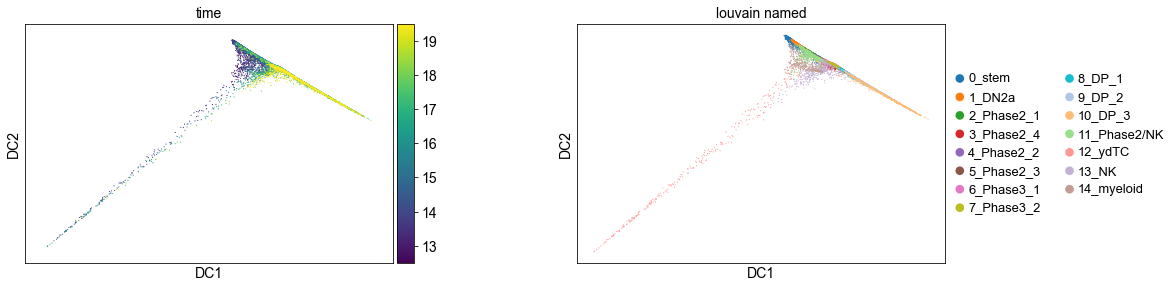

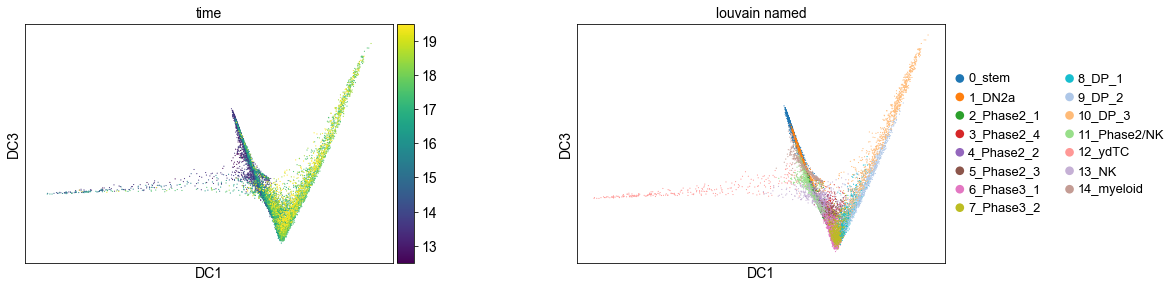

In [34]:
sc.pl.tsne(adata_old_red, color=['time', 'louvain_named'], size=5)
sc.pl.diffmap(adata_old_red, components='1,2', color=['time', 'louvain_named'], size=5)
sc.pl.diffmap(adata_old_red, components='1,3', color=['time', 'louvain_named'], size=5)

## Create trajectory tree

### Fit diffusion pseudotime as continuous coordinate along tree

Define root cell for diffusion pseudotime as extremum in diffusion map, guided by the time coordinate distribution across the diffusion map.

In [35]:
idxRoot = np.argmax(adata_old_red.obsm['X_diffmap'][:,2])
print(idxRoot) # 190
adata_old_red.uns['iroot'] = idxRoot

190


Compute diffusion pseudotime.

In [36]:
if bool_recomp:
    sc.tl.dpt(adata_old_red, n_branchings=1, n_dcs=10, min_group_size=20)
    sc.write('adata_old_red', adata_old_red, ext='h5')

Show diffusion pseudotime on diffusion map.

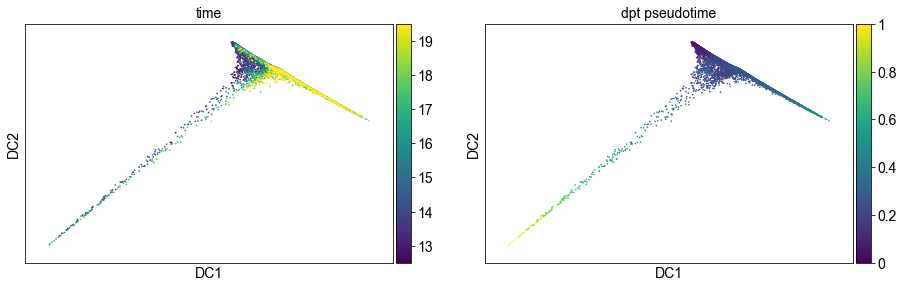

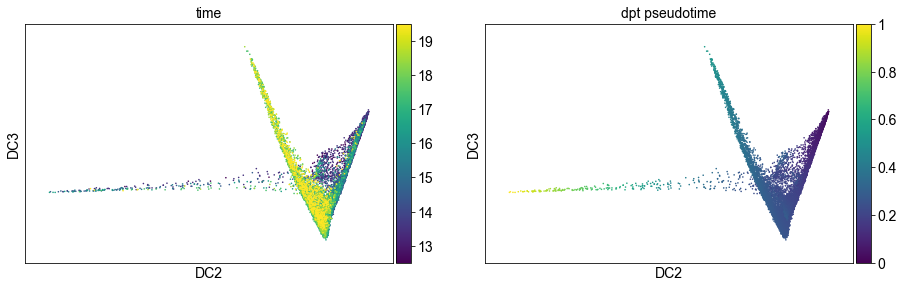

In [37]:
sc.pl.diffmap(adata_old_red, components='1,2', color=['time', 'dpt_pseudotime'], size=10)
sc.pl.diffmap(adata_old_red, components='2,3', color=['time', 'dpt_pseudotime'], size=10)

### Define branches of tree

Define branches based on louvain groups

In [38]:
branch_lg_dict = {0:'TC', 1:'TC', 2:'TC', 3:'TC', 4:'TC', 5:'TC', 6:'TC',
                      7:'TC', 8:'TC', 9:'TC', 10:'TC', 11:'TC', 
                      12:'NCL', 13:'TC', 14:'NCL'}
adata_old_red.obs['branch'] = [branch_lg_dict[x] for x in adata_old_red.obs['louvain'].values.astype(int)]

... storing 'branch' as categorical


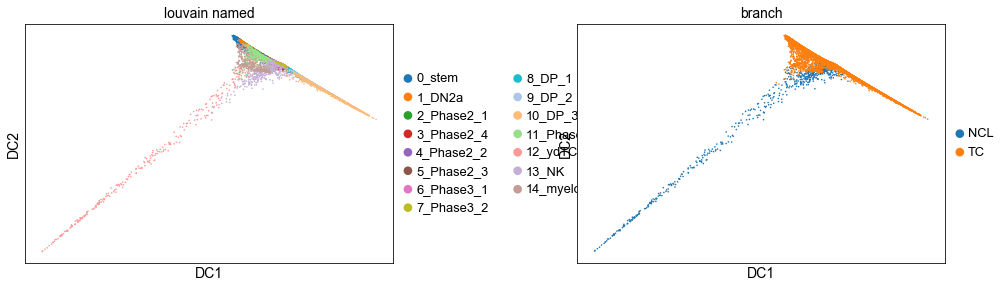

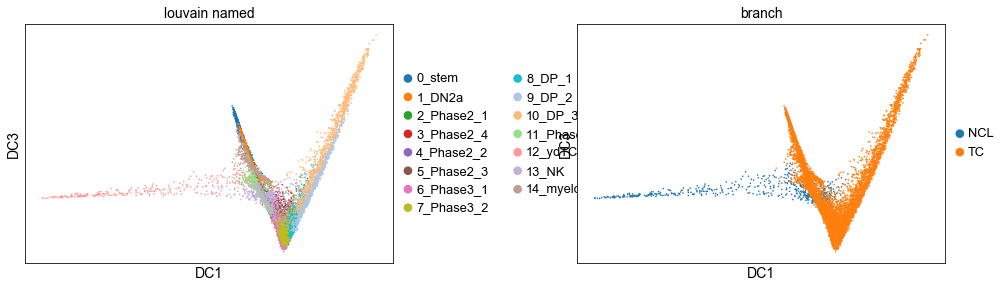

In [39]:
sc.pl.diffmap(adata_old_red, components='1,2', color=['louvain_named', 'branch'], size=10)
sc.pl.diffmap(adata_old_red, components='1,3', color=['louvain_named', 'branch'], size=10)

# Prepare pseudodynamics input

## Diffusion pseudotime based cell state and pseudodynamics model

### Define branches and branching regions.

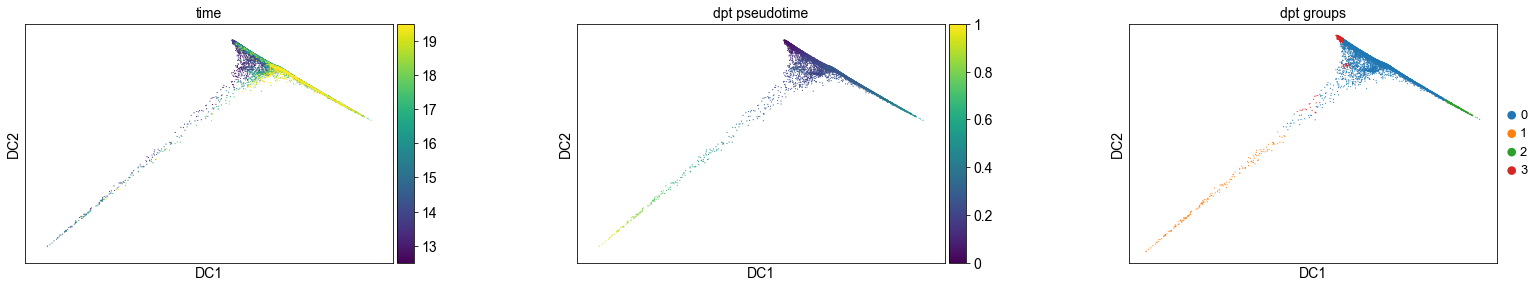

In [40]:
sc.pl.diffmap(adata_old_red, components='1,2', color=['time', 'dpt_pseudotime', 'dpt_groups'], size=5)

Rename dpt groups for convenience.

... storing 'dpt_groups_named' as categorical


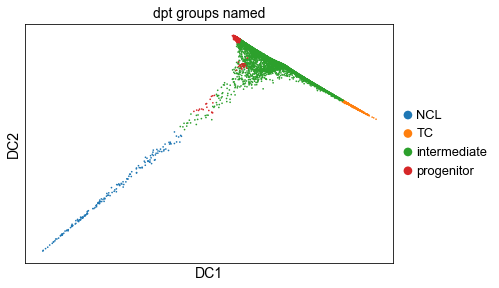

In [41]:
dict_dpt_groups_named = {'0':'intermediate', '1':'NCL', '2':'TC', '3':'progenitor'}
adata_old_red.obs['dpt_groups_named'] = [dict_dpt_groups_named[x] for x in adata_old_red.obs['dpt_groups'].values]
sc.pl.diffmap(adata_old_red, components='1,2', color=['dpt_groups_named'])

Assign progenitor labeled cells which lie above smallest dpt coordinate in intermediate group as intermediates

Minimum dpt observed for intermediate group: 0.03810754


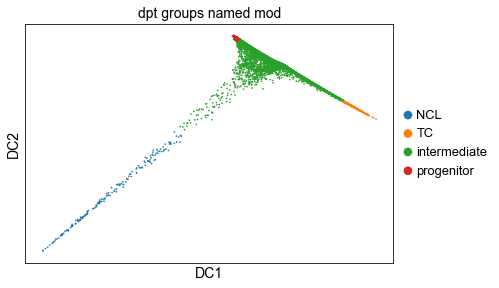

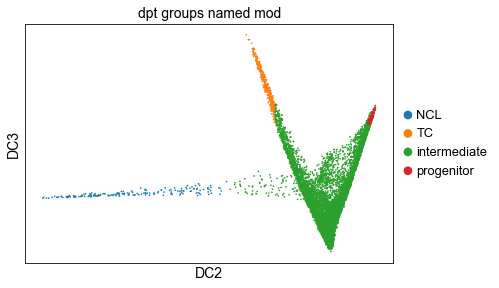

In [42]:
adata_old_red.obs['dpt_groups_named_mod'] = adata_old_red.obs['dpt_groups_named'] # modified group assignments
min_dpt_intermediates = np.min(adata_old_red[adata_old_red.obs['dpt_groups_named'].values=='intermediate',:].obs['dpt_pseudotime'])
print('Minimum dpt observed for intermediate group: '+str(min_dpt_intermediates ))
adata_old_red.obs.loc[np.logical_and(
    adata_old_red.obs['dpt_groups_named'].values=='progenitor',
    adata_old_red.obs['dpt_pseudotime'] > min_dpt_intermediates), 'dpt_groups_named_mod'] = 'intermediate'
sc.pl.diffmap(adata_old_red, components='1,2', color=['dpt_groups_named_mod'])
sc.pl.diffmap(adata_old_red, components='2,3', color=['dpt_groups_named_mod'])

Move start of T-cell group closer to branching region in DC1-DC2 scatter.

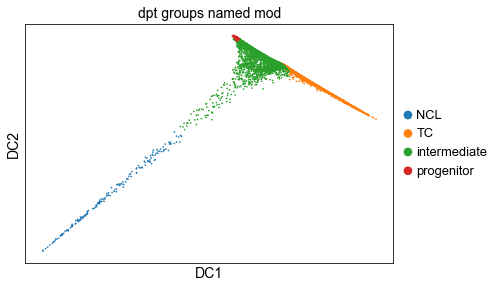

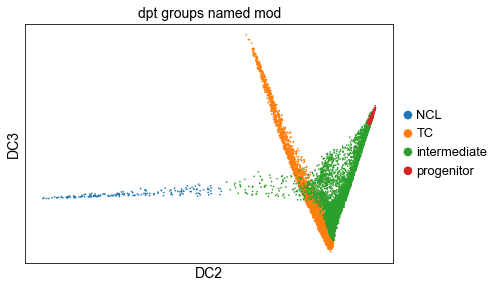

In [43]:
max_dpt_tc_intermediates = 0.25
adata_old_red.obs.loc[np.logical_and.reduce(np.asarray([
    adata_old_red.obs['dpt_groups_named'].values=='intermediate',
    adata_old_red.obs['dpt_pseudotime'] > max_dpt_tc_intermediates,
    adata_old_red.obsm['X_diffmap'][:,1] > 0,
    ])), 'dpt_groups_named_mod'] = 'TC'
sc.pl.diffmap(adata_old_red, components='1,2', color=['dpt_groups_named_mod'])
sc.pl.diffmap(adata_old_red, components='2,3', color=['dpt_groups_named_mod'])

Move non-conventional lymphocyte group start closer to branching region based on dpt threshold chosen for T-cell group.

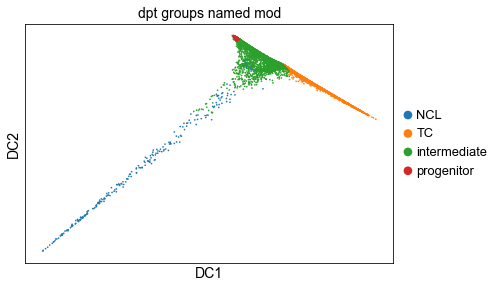

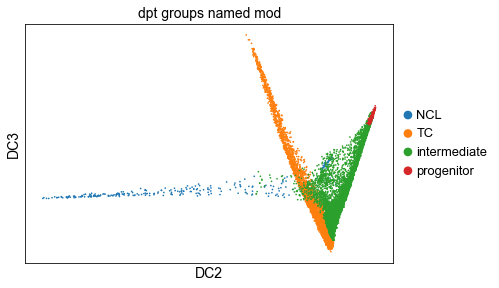

In [44]:
adata_old_red.obs.loc[np.logical_and.reduce(np.asarray([
    adata_old_red.obs['dpt_groups_named'].values=='intermediate',
    adata_old_red.obs['dpt_pseudotime'] > max_dpt_tc_intermediates,
    adata_old_red.obsm['X_diffmap'][:,1] < 0,
    ])), 'dpt_groups_named_mod'] = 'NCL'
sc.pl.diffmap(adata_old_red, components='1,2', color=['dpt_groups_named_mod'])
sc.pl.diffmap(adata_old_red, components='2,3', color=['dpt_groups_named_mod'])

Split intermediate group up to receive two trajectories: T-cells and branching natural killer cell trajectory. Do this via a linear decision plane ('cut') in DC1-DC2 plane.

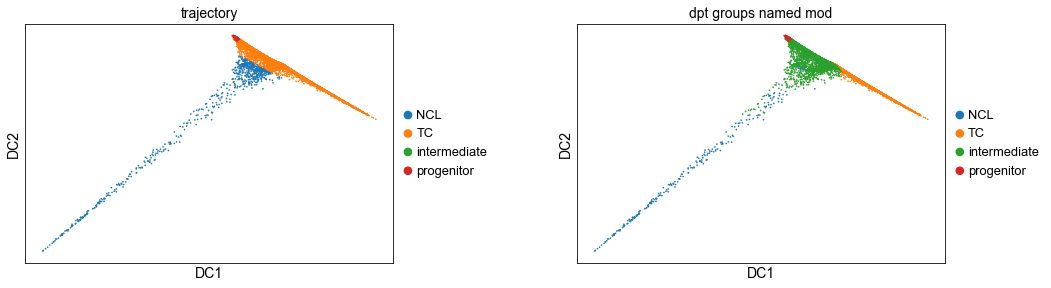

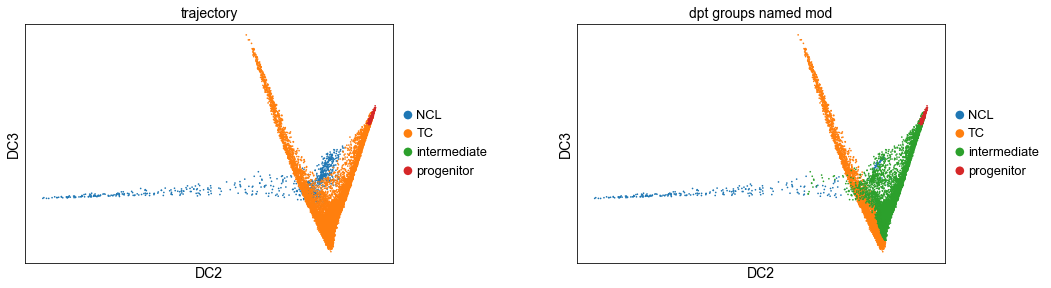

In [45]:
lm_dc12_slope = -4/5
lm_dc12_intercept = -0.002
adata_old_red.obs['trajectory'] = adata_old_red.obs['dpt_groups_named_mod']
adata_old_red.obs.loc[np.logical_and.reduce(np.asarray([
    adata_old_red.obs['dpt_groups_named_mod'].values=='intermediate',
    adata_old_red.obsm['X_diffmap'][:,2] > lm_dc12_intercept + lm_dc12_slope*adata_old_red.obsm['X_diffmap'][:,1]
    ])), 'trajectory'] = 'TC'
# Assign remaining cells (other side of decision boundary) to natural killer cell trajectory.
adata_old_red.obs.loc[adata_old_red.obs['trajectory'].values=='intermediate', 'trajectory'] = 'NCL'
sc.pl.diffmap(adata_old_red, components='1,2', color=['trajectory', 'dpt_groups_named_mod'])
sc.pl.diffmap(adata_old_red, components='2,3', color=['trajectory', 'dpt_groups_named_mod'])

Define branching region where cells are allowed to switch branches based on pseudotime interval of intermediates.

... storing 'branching' as categorical


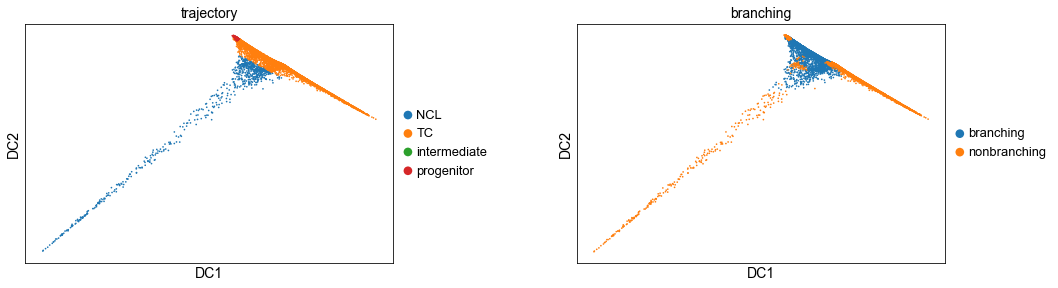

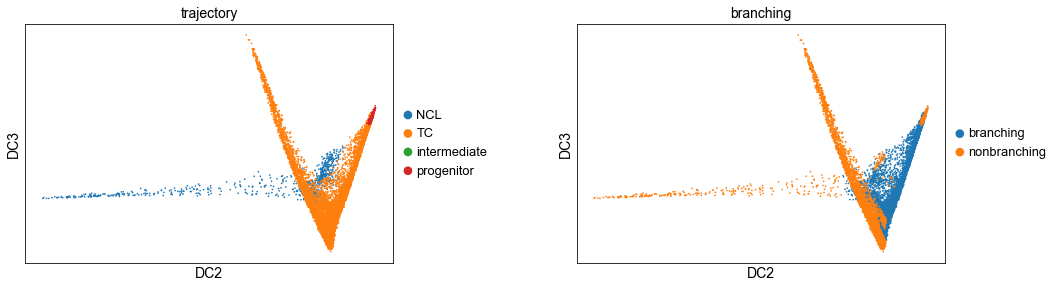

In [46]:
adata_old_red.obs['branching'] = 'nonbranching'
adata_old_red.obs.loc[np.logical_and.reduce(np.asarray([
    adata_old_red.obs['dpt_pseudotime'].values > min_dpt_intermediates,
    adata_old_red.obs['dpt_pseudotime'].values < max_dpt_tc_intermediates
    ])), 'branching'] = 'branching'
sc.pl.diffmap(adata_old_red, components='1,2', color=['trajectory', 'branching'])
sc.pl.diffmap(adata_old_red, components='2,3', color=['trajectory', 'branching'])

Scale pseudotime coordinates in the natural killer cell branch so that both branches end in the maximal coordinate of the T-cell branch.

Maximum dpt observed for T-cells: 0.5473179


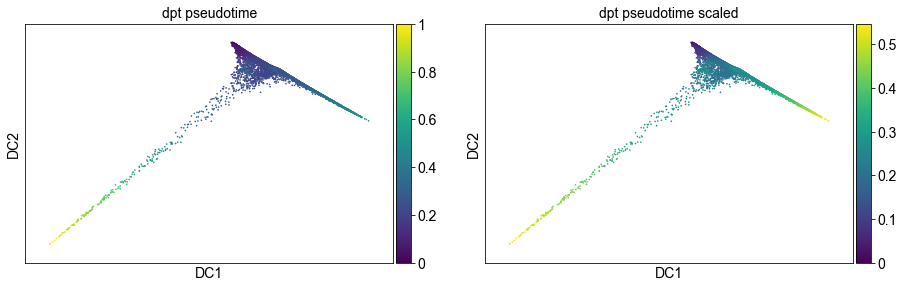

In [47]:
adata_old_red.obs['dpt_pseudotime_scaled'] = adata_old_red.obs['dpt_pseudotime']
max_dpt_tc = np.max(adata_old_red.obs.loc[adata_old_red.obs['trajectory'].values=='TC', 'dpt_pseudotime'])
span_dpt_tc = max_dpt_tc-max_dpt_tc_intermediates # Length of T-cell trajectory after branching region.
print('Maximum dpt observed for T-cells: '+str(max_dpt_tc ))
dpt_nk = adata_old_red.obs.loc[np.logical_and.reduce(np.asarray([
    adata_old_red.obs['trajectory'].values=='NCL',
    adata_old_red.obs['dpt_pseudotime'].values > max_dpt_tc_intermediates
    ])), 'dpt_pseudotime']
adata_old_red.obs.loc[np.logical_and.reduce(np.asarray([
    adata_old_red.obs['trajectory'].values=='NCL',
    adata_old_red.obs['dpt_pseudotime'].values > max_dpt_tc_intermediates
    ])), 'dpt_pseudotime_scaled'] = span_dpt_tc/(1-max_dpt_tc_intermediates)*(dpt_nk-max_dpt_tc_intermediates)+max_dpt_tc_intermediates
sc.pl.diffmap(adata_old_red, components='1,2', color=['dpt_pseudotime', 'dpt_pseudotime_scaled'])

### Prepare pseudodynamics input table.

This is the text file that is used in the Matlab code that we use to fit the pseudodynamics model (the system of partial differential equations).

In [48]:
pd_in = pandas.DataFrame({
    'pseudodynamics_branching_region':adata_old_red.obs['branching'],
    'pseudodynamics_branch_class':adata_old_red.obs['trajectory'],
    'dpt_adjusted_groups':adata_old_red.obs['dpt_groups_named_mod'],
    'time':adata_old_red.obs['time'],
    'batch':adata_old_red.obs['groups'],
    'pseudotime':adata_old_red.obs['dpt_pseudotime_scaled'],
    'cell':adata_old_red.obs_names,
    'dc1':-adata_old_red.obsm['X_diffmap'][:,1], # diffmap is negative of what it was before (flipped)
    'dc2':-adata_old_red.obsm['X_diffmap'][:,2],
    'dc3':-adata_old_red.obsm['X_diffmap'][:,3],
    'dc4':-adata_old_red.obsm['X_diffmap'][:,4]
})

In [49]:
if bool_recomp==True:
    pd_in.to_csv(
        path_or_buf =dir_out+"scanpy_1_04/pseudodynamics_input_maehr17_dpt_branching_TCandNK.csv")

## Monocle2 based cell state and pseudodynamics model

We ran monocle2 in a separate R script and only select the cells for a linear trajectory model without branching here.

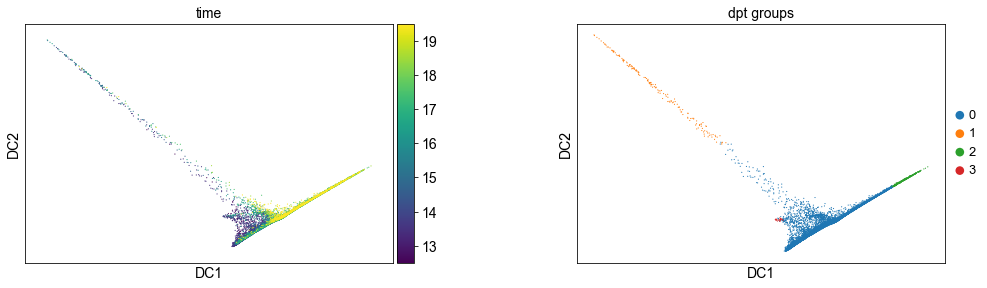

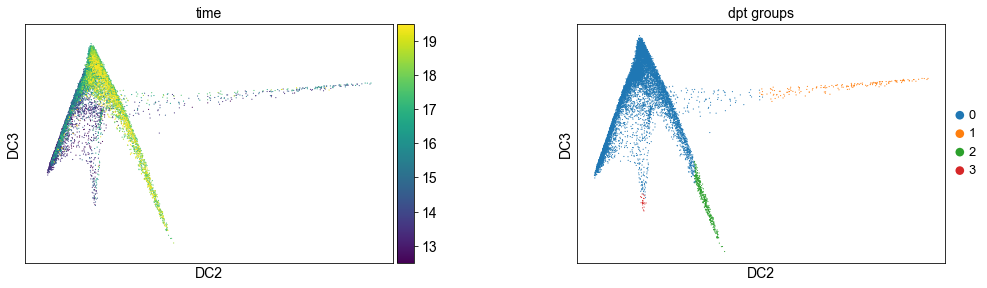

In [50]:
sc.pl.diffmap(adata_old, components='1,2', color=['time', 'dpt_groups'], size=5)
sc.pl.diffmap(adata_old, components='2,3', color=['time', 'dpt_groups'], size=5)

Rename dpt groups for convenience.

... storing 'dpt_groups_named' as categorical


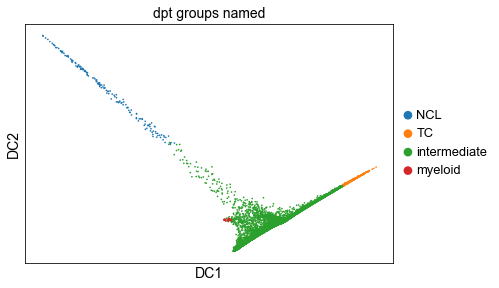

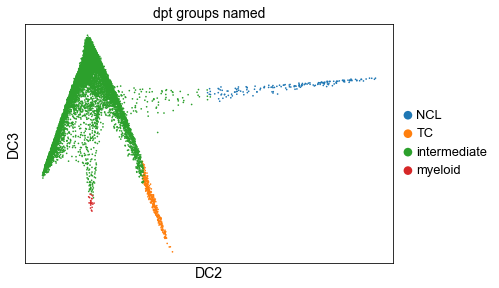

In [51]:
dict_dpt_groups_named = {'0':'intermediate', '1':'NCL', '2':'TC', '3':'myeloid'}
adata_old.obs['dpt_groups_named'] = [dict_dpt_groups_named[x] for x in adata_old.obs['dpt_groups'].values]
sc.pl.diffmap(adata_old, components='1,2', color=['dpt_groups_named'])
sc.pl.diffmap(adata_old, components='2,3', color=['dpt_groups_named'])

Gate out putative myeloid or dendritic cells and NCLs to receive a set of cells that can be described with the linear T-cell trajectory model.

In [52]:
monocle2_gate = np.array([dict_dpt_groups_named[x] in ['intermediate', 'TC'] 
                          for x in adata_old.obs['dpt_groups'].values])
print("monocle2: all cells gated out: ", len(monocle2_gate) - monocle2_gate.sum())
print("monocle2: all cells kept: ", monocle2_gate.sum())
adata_old.obs["gated_monocle2"] = ['yes' if x==True else 'no' for x in monocle2_gate]

monocle2: all cells gated out:  190
monocle2: all cells kept:  10705


# Save results

In [53]:
if bool_recomp==True:
    np.savetxt(dir_out+"scanpy_1_04/DiffMap_maehr17_new.csv", 
               adata_new.obsm['X_diffmap'], delimiter=",")
    np.savetxt(dir_out+"scanpy_1_04/Tsne_maehr17_new.csv", 
               adata_new.obsm['X_tsne'], delimiter=",")
    pandas.DataFrame(adata_new.obs).to_csv(
        path_or_buf =dir_out+"scanpy_1_04/obs_maehr17_new.csv")

In [54]:
if bool_recomp==True:
    np.savetxt(dir_out+"scanpy_1_04/DiffMap_maehr17_old.csv", 
               adata_old.obsm['X_diffmap'], delimiter=",")
    pandas.DataFrame(adata_old.obs).to_csv(
        path_or_buf =dir_out+"scanpy_1_04/obs_maehr17_old.csv")

In [55]:
if bool_recomp==True:
    np.savetxt(dir_out+"scanpy_1_04/DiffMap_maehr17_old_gate.csv", 
               adata_old_red.obsm['X_diffmap'], delimiter=",")
    pandas.DataFrame(adata_old_red.obs).to_csv(
        path_or_buf =dir_out+"scanpy_1_04/obs_maehr17_old_gate.csv")

In [56]:
if bool_write_cluster_cache==True:
    pandas.DataFrame(adata_new.obs).to_csv(
        path_or_buf =dir_out+"scanpy_1_04/obs_maehr17_clustering.csv")

# Compare against old results

Pseudodynamics model fitting is very computation intentsive, we ran pseudodynamics on an an embedding created with an older version of scnapy. We provide this section of the notebook to show that this old embedding is similar to the embedding that is created with newer versions of scanpy (this notebook was written for 1.2).

### Raw embeddings

In [57]:
obs_old = pandas.read_csv(dir_out+'dimreds/dpt_maehr17_gate.csv')
obs_new = adata_old_red.obs
obs_new['obs_names'] = adata_old_red.obs_names

In [58]:
obs_old = obs_old.iloc[np.where([x in obs_new['obs_names'].values for x in obs_old['smp_names'].values])[0],:]
obs_names_new = adata_old_red.obs_names[np.where([x in obs_old['smp_names'].values for x in obs_new['obs_names'].values])[0]]
diffmap_new = -adata_old_red.obsm['X_diffmap'][np.where( # diffmap is negative of what it was before
    [x in obs_old['smp_names'].values for x in obs_new['obs_names'].values])[0],:]
obs_new = obs_new.iloc[np.where([x in obs_old['smp_names'].values for x in obs_new['obs_names'].values])[0],:]

In [59]:
print('Cell IDs are the same: '+str(all(obs_names_new==obs_old['smp_names'].values)))
print('Maximum deviation in pseudotime: '+
      str(np.max(np.abs(obs_old['dpt_pseudotime'].values - obs_new['dpt_pseudotime'].values))))
print('Maximum deviation in DC1: '+str(np.max(np.abs(obs_old['X_diffmap001of009'].values-diffmap_new[:,1]))))
print('Maximum deviation in DC2: '+str(np.max(np.abs(obs_old['X_diffmap002of009'].values-diffmap_new[:,2]))))
print('Number of DPT group labels are not the same: '+str(np.sum(obs_old['dpt_groups'].values!=obs_new['dpt_groups'].values.astype(int))))

Cell IDs are the same: True
Maximum deviation in pseudotime: 2.6494264602661133e-05
Maximum deviation in DC1: 3.91155481338501e-07
Maximum deviation in DC2: 4.3585896491310505e-07
Number of DPT group labels are not the same: 0


### Processed input for pseudodynamics

In [60]:
in_old = pandas.read_csv(dir_out+'input/pseudodynamics_input_maehr17_dpt_branching_TCandNK.csv')

In [61]:
print('Dimensions of input objects match: '+str(np.all(in_old.shape==pd_in.shape)))
print('Column names of input objects match: '+str(np.all(in_old.columns==pd_in.columns)))

Dimensions of input objects match: True
Column names of input objects match: True


Test equality of selected columns. NCL were previously called NK.

In [62]:
print('pseudodynamics_branching_region labels are the same: '+
      str(all(in_old['pseudodynamics_branching_region'].values==pd_in['pseudodynamics_branching_region'].values)))
print('pseudodynamics_branch_class labels are the same: '+
      str(all(np.asarray([{'NK':'NCL', 'TC':'TC', 'progenitor':'progenitor'}[x] 
                          for x in in_old['pseudodynamics_branch_class'].values]) ==
              pd_in['pseudodynamics_branch_class'].values)))
print('dpt_adjusted_groups labels are the same: '+
      str(np.all(np.asarray([{'NK':'NCL', 'TC':'TC', 'progenitor':'progenitor', 'intermediate':'intermediate'}[x] 
                          for x in in_old['dpt_adjusted_groups'].values]) ==
                 pd_in['dpt_adjusted_groups'].values)))
print('Cell IDs are the same: '+str(all(in_old['cell'].values==pd_in['cell'].values)))
print('Batch IDs are the same: '+str(all(in_old['batch'].values==pd_in['batch'].values)))
print('Time labels are the same: '+str(all(in_old['time'].values==pd_in['time'].values)))

pseudodynamics_branching_region labels are the same: True
pseudodynamics_branch_class labels are the same: True
dpt_adjusted_groups labels are the same: True
Cell IDs are the same: True
Batch IDs are the same: True
Time labels are the same: True


In [63]:
print('Maximum deviation in pseudotime: '+str(np.max(np.abs(in_old['pseudotime'].values-pd_in['pseudotime'].values))))
print('Maximum deviation in DC1: '+str(np.max(np.abs(in_old['dc1'].values-pd_in['dc1'].values))))
print('Maximum deviation in DC2: '+str(np.max(np.abs(in_old['dc2'].values-pd_in['dc2'].values))))
print('Maximum deviation in DC3: '+str(np.max(np.abs(in_old['dc3'].values-pd_in['dc3'].values))))
print('Maximum deviation in DC4: '+str(np.max(np.abs(in_old['dc4'].values-pd_in['dc4'].values))))

Maximum deviation in pseudotime: 2.682209015170134e-06
Maximum deviation in DC1: 8.381903171747473e-07
Maximum deviation in DC2: 8.419156074732093e-07
Maximum deviation in DC3: 2.272427082027073e-07
Maximum deviation in DC4: 5.494803190057851e-07
